# 08_baseline_RL - Reinforcement Learning baseline para trading DOGEUSDT

Este notebook implementa un primer enfoque simplificado de aprendizaje por refuerzo aplicado al problema de trading algorítmico del TFM.

El objetivo no es obtener un agente óptimo ni una estrategia lista para producción, sino construir una prueba funcional, reproducible y comparable con los enfoques anteriores del proyecto.

El experimento se plantea con un entorno compatible con Gym, tres acciones discretas y una política entrenada mediante Q-learning tabular sobre una discretización sencilla del estado.

- Acción 0: HOLD
- Acción 1: BUY
- Acción 2: SELL

La evaluación final compara la curva de equity del agente RL frente a una estrategia Buy & Hold sobre el tramo temporal reservado para test.

## Alcance del notebook

Este notebook cubre una versión baseline de RL con alcance deliberadamente limitado:

- Se utiliza un entorno long-only simplificado
- El agente puede estar en cash o en posición larga
- Se aplican fees y slippage aproximados
- El reward se basa en la variación logarítmica de equity entre pasos
- El entrenamiento se realiza durante pocos episodios para mantener el coste computacional bajo
- La comparación se realiza contra Buy & Hold en el periodo de evaluación

La finalidad académica es documentar que el proyecto explora la toma de decisiones secuenciales mediante aprendizaje por refuerzo, manteniendo trazabilidad con el pipeline previo de features, backtesting y métricas financieras.

## Contexto metodológico

A diferencia del pipeline supervisado tradicional utilizado en notebooks anteriores, en aprendizaje por refuerzo el entrenamiento y la evaluación operativa se encuentran parcialmente integrados dentro del propio entorno de simulación.

En el enfoque supervisado, el flujo habitual separa claramente:

- Entrenamiento del modelo
- Generación de predicciones
- Backtesting posterior sobre las señales generadas

Sin embargo, en reinforcement learning el agente aprende directamente interactuando con un entorno secuencial que ya incorpora decisiones operativas, rewards y evolución temporal del mercado.

Por este motivo, las distintas versiones RL del proyecto se estructuran como iteraciones sucesivas del agente y del entorno, en lugar de separar explícitamente entrenamiento y backtesting como se hizo en el bloque de machine learning supervisado.

El objetivo de esta primera versión no es maximizar rentabilidad ni construir un sistema de trading robusto, sino validar una arquitectura RL mínima y funcional sobre datos financieros reales.

Como ya se comentó en notebooks anteriores, los mercados financieros presentan un entorno altamente no estacionario, con fuerte presencia de ruido y sensibilidad a costes operativos, lo que convierte el aprendizaje por refuerzo en un problema especialmente complejo incluso en escenarios simplificados.


In [1]:
# ============================================================
# Imports and global configuration
# Se cargan las librerías principales y se define la configuración general del experimento RL.
# El notebook evita dependencias pesadas de RL para mantener una implementación sencilla, reproducible y ejecutable en entorno local.
# ============================================================

from pathlib import Path
from collections import defaultdict
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import gymnasium as gym
    from gymnasium import spaces
    GYM_BACKEND = "gymnasium"
except ImportError:
    try:
        import gym
        from gym import spaces
        GYM_BACKEND = "gym"
    except ImportError as exc:
        raise ImportError(
            "No se ha encontrado gymnasium ni gym. Instala una de estas dependencias antes de ejecutar el notebook: "
            "pip install gymnasium"
        ) from exc

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INITIAL_BALANCE = 1000.0
FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0005
TRAIN_FRACTION = 0.80
MAX_TRAIN_EPISODE_STEPS = 2_000
N_EPISODES = 30

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Gym backend: {GYM_BACKEND}")
print(f"Results directory: {RESULTS_DIR.resolve()}")


Gym backend: gymnasium
Results directory: C:\Users\elwya\Documents\programacion\python\jupyter notebook\M10\TFM\Repository\cryptobot-tfm\results


In [2]:
# ============================================================
# Load engineered DOGEUSDT dataset
# Se carga el dataset enriquecido generado en el pipeline de feature engineering.
# ============================================================

DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró el dataset enriquecido. Revisa la ruta definida en DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

if "open_time" in df.columns:
    df["open_time"] = pd.to_datetime(df["open_time"])
    df = df.sort_values("open_time").reset_index(drop=True)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())

Dataset loaded from: ..\data\processed\DOGEUSDT_5m_binance_2017_2026_features.csv
Shape: (723080, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-06 11:55:00,0.003630,0.003644,0.003630,0.003635,472036.0,2019-07-06 11:59:59.999,1718.044681,24,405943.0,...,0.081048,0.00355,0.004600,0.023411,0.265440,0,0,0.0,0.0,0.0
1,2019-07-06 12:00:00,0.003632,0.003638,0.003629,0.003637,799853.0,2019-07-06 12:04:59.999,2908.008956,18,292138.0,...,0.109846,0.00355,0.004340,0.023867,0.193412,0,0,0.0,0.0,0.0
2,2019-07-06 12:05:00,0.003634,0.003637,0.003625,0.003637,2176492.0,2019-07-06 12:09:59.999,7909.776304,42,1028365.0,...,0.166956,0.00355,0.004069,0.023813,0.118820,0,0,0.0,0.0,0.0
3,2019-07-06 12:10:00,0.003636,0.003636,0.003620,0.003620,618720.0,2019-07-06 12:14:59.999,2240.639784,16,33792.0,...,0.168759,0.00355,0.003964,0.019310,0.095113,0,0,0.0,0.0,0.0
4,2019-07-06 12:15:00,0.003621,0.003627,0.003610,0.003611,1808302.0,2019-07-06 12:19:59.999,6538.506892,30,450314.0,...,0.147272,0.00355,0.003964,0.016893,0.097812,0,0,0.0,0.0,0.0


In [3]:
# ============================================================
# Dataset validation and feature selection
# Se validan las columnas necesarias y se seleccionan únicamente variables disponibles en el pasado o presente para evitar leakage.
# Las columnas target futuras se excluyen explícitamente porque el agente no debe observar información del futuro.
# ============================================================

required_columns = ["close"]
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

excluded_columns = [
    "open_time",
    "close_time",
    "future_close_1",
    "future_return_1",
    "up_1",
    "future_close_3",
    "future_return_3",
    "up_3",
    "future_close_6",
    "future_return_6",
    "up_6",
    "future_close_12",
    "future_return_12",
    "up_12",
]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in excluded_columns and col != "close"]

preferred_rl_features = [
    "return_prev_1",
    "log_return_prev_1",
    "ema10_ema50_ratio",
    "ema50_ema200_ratio",
    "sma20_ema50_ratio",
    "volatility_1h",
    "zscore_close_1h",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_hist",
    "bb_width",
    "bb_percent",
    "atr_14",
    "price_position_in_recent_range",
    "dist_to_nearest_support",
    "dist_to_nearest_resistance",
    "near_support",
    "near_resistance",
    "support_strength",
    "resistance_strength",
    "touch_count_near_level",
]

feature_cols = [col for col in preferred_rl_features if col in feature_cols]

if len(feature_cols) == 0:
    raise ValueError("No se encontraron features válidas para el entorno RL.")

rl_df = df[["open_time", "close"] + feature_cols].copy() if "open_time" in df.columns else df[["close"] + feature_cols].copy()
rl_df = rl_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f"Number of selected RL features: {len(feature_cols)}")
display(pd.DataFrame({"feature": feature_cols}))
print(f"RL dataset shape after cleaning: {rl_df.shape}")


Number of selected RL features: 22


,feature
0,return_prev_1
1,log_return_prev_1
2,ema10_ema50_ratio
3,ema50_ema200_ratio
4,sma20_ema50_ratio
5,volatility_1h
6,zscore_close_1h
7,rsi_14
8,macd
9,macd_signal


RL dataset shape after cleaning: (723080, 24)


In [4]:
# ============================================================
# Temporal train-test split and feature scaling
# Se separa el dataset en entrenamiento y test siguiendo orden temporal, evitando mezclar observaciones futuras en el entrenamiento.
# El escalado se ajusta solo con train y después se aplica a test para evitar contaminación temporal.
# ============================================================

split_idx = int(len(rl_df) * TRAIN_FRACTION)
train_df = rl_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df = rl_df.iloc[split_idx:].copy().reset_index(drop=True)

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_df[feature_cols])
test_features_scaled = scaler.transform(test_df[feature_cols])

train_scaled_df = train_df.copy()
test_scaled_df = test_df.copy()
train_scaled_df[feature_cols] = train_features_scaled
test_scaled_df[feature_cols] = test_features_scaled

split_summary = {
    "total_rows": len(rl_df),
    "train_rows": len(train_scaled_df),
    "test_rows": len(test_scaled_df),
    "train_start": train_df["open_time"].iloc[0] if "open_time" in train_df.columns else None,
    "train_end": train_df["open_time"].iloc[-1] if "open_time" in train_df.columns else None,
    "test_start": test_df["open_time"].iloc[0] if "open_time" in test_df.columns else None,
    "test_end": test_df["open_time"].iloc[-1] if "open_time" in test_df.columns else None,
}

split_summary_df = pd.DataFrame([split_summary])
display(split_summary_df)


,total_rows,train_rows,test_rows,train_start,train_end,test_start,test_end
0,723080,578464,144616,2019-07-06 11:55:00,2025-01-06 06:50:00,2025-01-06 06:55:00,2026-05-23 10:10:00


## Comentarios - Split temporal

El dataset procesado contiene 723.080 observaciones tras la limpieza previa, con una partición temporal 80/20.

El tramo de entrenamiento cubre desde 2019-07-06 hasta 2025-01-06, mientras que el tramo de test se reserva desde 2025-01-06 hasta 2026-05-23.

Esta separación mantiene la lógica temporal necesaria para evitar leakage: el agente se entrena únicamente con datos pasados y se evalúa sobre un periodo posterior no utilizado durante el aprendizaje.

El periodo de test incluye un tramo amplio y reciente del mercado, por lo que la evaluación permite observar si la política aprendida generaliza fuera del histórico usado para actualizar la Q-table.


In [5]:
# ============================================================
# Trading environment definition
# Se define un entorno compatible con Gym para simular decisiones secuenciales de trading con acciones BUY, HOLD y SELL.
# El entorno es long-only, aplica costes aproximados y calcula el reward como cambio logarítmico de equity entre pasos.
# ============================================================

class DogeTradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        data,
        feature_columns,
        initial_balance=1000.0,
        fee_rate=0.001,
        slippage_rate=0.0005,
        random_start=False,
        max_episode_steps=None,
        seed=42,
    ):
        super().__init__()
        self.data = data.reset_index(drop=True).copy()
        self.feature_columns = feature_columns
        self.initial_balance = float(initial_balance)
        self.fee_rate = float(fee_rate)
        self.slippage_rate = float(slippage_rate)
        self.random_start = random_start
        self.max_episode_steps = max_episode_steps
        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Discrete(3)
        obs_size = len(self.feature_columns) + 2
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float32)

        self.reset()

    def _get_price(self):
        return float(self.data.loc[self.current_step, "close"])

    def _get_equity(self):
        price = self._get_price()
        return self.cash + self.asset_units * price

    def _get_observation(self):
        features = self.data.loc[self.current_step, self.feature_columns].to_numpy(dtype=np.float32)
        equity = max(self._get_equity(), 1e-12)
        position_flag = np.float32(1.0 if self.asset_units > 0 else 0.0)
        cash_ratio = np.float32(self.cash / equity)
        return np.concatenate([features, [position_flag, cash_ratio]]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.default_rng(seed)

        max_start = max(1, len(self.data) - (self.max_episode_steps or len(self.data)) - 2)
        if self.random_start and max_start > 1:
            self.current_step = int(self.rng.integers(0, max_start))
        else:
            self.current_step = 0

        self.start_step = self.current_step
        self.cash = self.initial_balance
        self.asset_units = 0.0
        self.last_equity = self.initial_balance
        self.trade_log = []
        self.equity_curve = []
        self.action_history = []

        obs = self._get_observation()
        info = {"equity": self.last_equity}
        return obs, info

    def step(self, action):
        action = int(action)
        price = self._get_price()
        previous_equity = max(self._get_equity(), 1e-12)
        executed_trade = "HOLD"

        if action == 1 and self.asset_units == 0 and self.cash > 0:
            execution_price = price * (1 + self.slippage_rate)
            cash_after_fee = self.cash * (1 - self.fee_rate)
            self.asset_units = cash_after_fee / execution_price
            self.cash = 0.0
            executed_trade = "BUY"
            self.trade_log.append({"step": self.current_step, "action": executed_trade, "price": price})

        elif action == 2 and self.asset_units > 0:
            execution_price = price * (1 - self.slippage_rate)
            gross_cash = self.asset_units * execution_price
            self.cash = gross_cash * (1 - self.fee_rate)
            self.asset_units = 0.0
            executed_trade = "SELL"
            self.trade_log.append({"step": self.current_step, "action": executed_trade, "price": price})

        self.current_step += 1

        reached_end = self.current_step >= len(self.data) - 1
        reached_max_steps = self.max_episode_steps is not None and (self.current_step - self.start_step) >= self.max_episode_steps
        terminated = reached_end
        truncated = bool(reached_max_steps and not reached_end)

        current_equity = max(self._get_equity(), 1e-12)
        reward = np.log(current_equity / previous_equity)

        if executed_trade != "HOLD":
            reward -= 0.00001

        self.last_equity = current_equity
        self.equity_curve.append(current_equity)
        self.action_history.append(action)

        obs = self._get_observation()
        info = {
            "equity": current_equity,
            "price": self._get_price(),
            "executed_trade": executed_trade,
            "position": 1 if self.asset_units > 0 else 0,
        }

        return obs, float(reward), terminated, truncated, info


In [6]:
# ============================================================
# Environment smoke test
# Se ejecuta una prueba corta con acciones aleatorias para validar que el entorno avanza, calcula equity y registra operaciones sin errores.
# Esta celda no evalúa rendimiento, solo comprueba integridad básica del entorno.
# ============================================================

env_check = DogeTradingEnv(
    train_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    random_start=True,
    max_episode_steps=100,
    seed=RANDOM_STATE,
)

obs, info = env_check.reset(seed=RANDOM_STATE)
smoke_rewards = []

for _ in range(100):
    action = env_check.action_space.sample()
    obs, reward, terminated, truncated, info = env_check.step(action)
    smoke_rewards.append(reward)
    if terminated or truncated:
        break

smoke_summary = {
    "steps_executed": len(smoke_rewards),
    "final_equity": info["equity"],
    "total_reward": np.sum(smoke_rewards),
    "num_logged_trades": len(env_check.trade_log),
}

smoke_summary_df = pd.DataFrame([smoke_summary])
display(smoke_summary_df)


,steps_executed,final_equity,total_reward,num_logged_trades
0,100,958.720767,-0.042485,33


In [7]:
# ============================================================
# Q-learning helper functions
# Se implementa una política Q-learning tabular sobre una discretización sencilla del estado observado por el entorno.
# Esta aproximación es deliberadamente simple y sirve como baseline RL interpretable antes de usar algoritmos más avanzados.
# ============================================================

selected_state_features = [
    col for col in [
        "return_prev_1",
        "zscore_close_1h",
        "rsi_14",
        "macd_hist",
        "bb_percent",
        "price_position_in_recent_range",
        "volatility_1h",
    ]
    if col in feature_cols
]

state_feature_indices = [feature_cols.index(col) for col in selected_state_features]
position_index = len(feature_cols)
cash_ratio_index = len(feature_cols) + 1

state_bins = np.array([-1.5, -0.75, 0.0, 0.75, 1.5])


def discretize_observation(obs):
    feature_state = tuple(np.digitize(obs[idx], state_bins) for idx in state_feature_indices)
    position_state = int(obs[position_index] > 0.5)
    cash_state = int(obs[cash_ratio_index] > 0.5)
    return feature_state + (position_state, cash_state)


def choose_action(q_table, state, epsilon, n_actions=3):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(q_table[state]))

print(f"State features used by Q-learning: {selected_state_features}")


State features used by Q-learning: ['return_prev_1', 'zscore_close_1h', 'rsi_14', 'macd_hist', 'bb_percent', 'price_position_in_recent_range', 'volatility_1h']


In [8]:
# ============================================================
# Train tabular Q-learning agent
# Se entrena un agente Q-learning durante un número reducido de episodios con inicios aleatorios dentro del tramo de entrenamiento.
# El objetivo es obtener una política RL baseline, no optimizar exhaustivamente la estrategia.
# ============================================================

train_env = DogeTradingEnv(
    train_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    random_start=True,
    max_episode_steps=MAX_TRAIN_EPISODE_STEPS,
    seed=RANDOM_STATE,
)

q_table = defaultdict(lambda: np.zeros(train_env.action_space.n, dtype=np.float64))

alpha = 0.08
gamma = 0.95
epsilon_start = 1.00
epsilon_end = 0.05
epsilon_decay = 0.92

episode_metrics = []
epsilon = epsilon_start

for episode in range(1, N_EPISODES + 1):
    obs, info = train_env.reset(seed=RANDOM_STATE + episode)
    state = discretize_observation(obs)
    total_reward = 0.0
    done = False
    steps = 0

    while not done:
        action = choose_action(q_table, state, epsilon, train_env.action_space.n)
        next_obs, reward, terminated, truncated, info = train_env.step(action)
        next_state = discretize_observation(next_obs)

        best_next_q = np.max(q_table[next_state])
        q_table[state][action] += alpha * (reward + gamma * best_next_q - q_table[state][action])

        state = next_state
        total_reward += reward
        steps += 1
        done = terminated or truncated

    episode_metrics.append({
        "episode": episode,
        "steps": steps,
        "total_reward": total_reward,
        "final_equity": info["equity"],
        "epsilon": epsilon,
        "num_trades": len(train_env.trade_log),
    })

    epsilon = max(epsilon_end, epsilon * epsilon_decay)

training_metrics_df = pd.DataFrame(episode_metrics)
display(training_metrics_df.tail(10))
print(f"Number of learned states: {len(q_table)}")


,episode,steps,total_reward,final_equity,epsilon,num_trades
20,21,2000,-0.167710,846.952782,0.188693,160
21,22,2000,-0.248786,781.315681,0.173598,201
22,23,2000,-0.205962,815.004341,0.159710,140
23,24,2000,-0.177817,838.251424,0.146933,138
24,25,2000,-0.158241,854.883028,0.135179,145
25,26,2000,-0.260526,771.609790,0.124364,125
26,27,2000,-0.194352,824.669754,0.114415,158
27,28,2000,-0.080589,923.532407,0.105262,104
28,29,2000,-0.178820,837.410993,0.096841,138
29,30,2000,-0.127308,881.457789,0.089094,113


Number of learned states: 9558


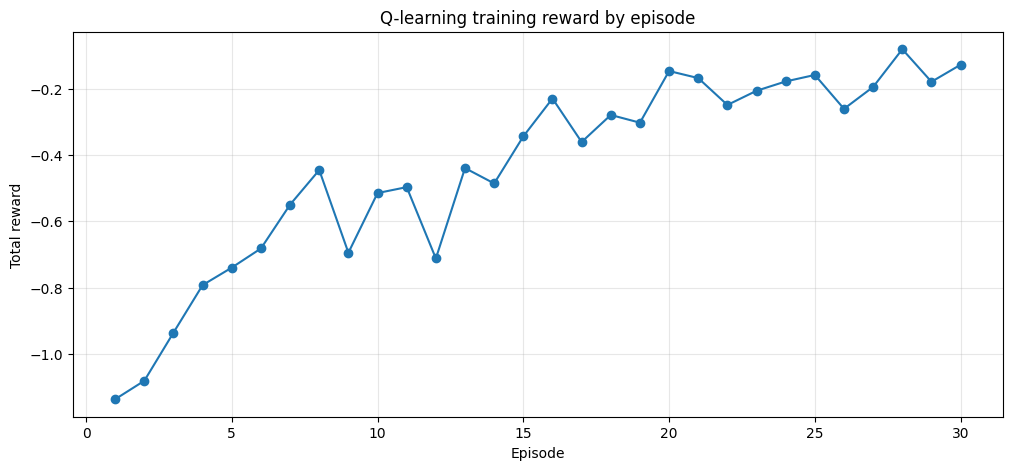

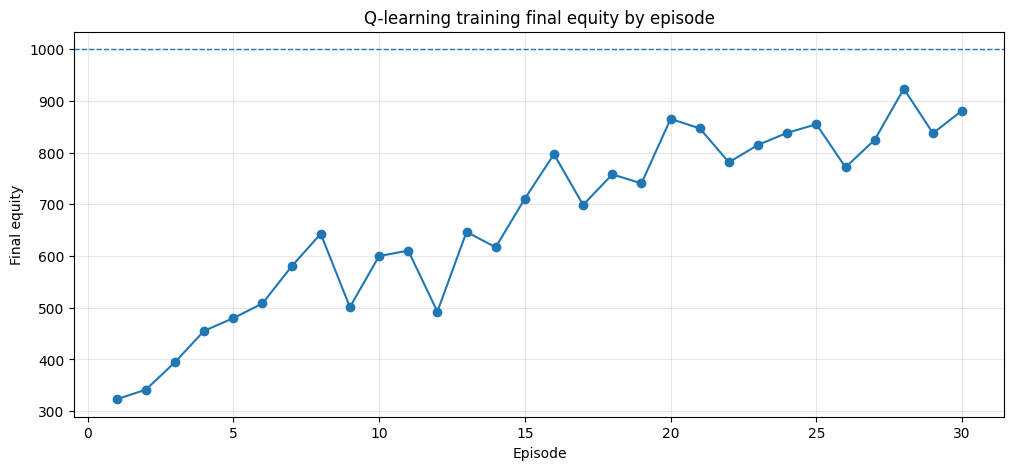

,episodes,mean_total_reward,best_total_reward,worst_total_reward,mean_final_equity,best_final_equity,worst_final_equity,mean_num_trades
0,30,-0.438882,-0.080589,-1.136764,671.246073,923.532407,322.948006,294.366667


In [9]:
# ============================================================
# Training diagnostics
# Se visualiza la evolución del reward y del equity final durante el entrenamiento para comprobar si el agente aprende una política mínimamente estable.
# Las gráficas se complementan con una tabla resumen para facilitar la interpretación posterior.
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(training_metrics_df["episode"], training_metrics_df["total_reward"], marker="o")
ax.set_title("Q-learning training reward by episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Total reward")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(training_metrics_df["episode"], training_metrics_df["final_equity"], marker="o")
ax.axhline(INITIAL_BALANCE, linestyle="--", linewidth=1)
ax.set_title("Q-learning training final equity by episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Final equity")
ax.grid(True, alpha=0.3)
plt.show()

training_summary = {
    "episodes": len(training_metrics_df),
    "mean_total_reward": training_metrics_df["total_reward"].mean(),
    "best_total_reward": training_metrics_df["total_reward"].max(),
    "worst_total_reward": training_metrics_df["total_reward"].min(),
    "mean_final_equity": training_metrics_df["final_equity"].mean(),
    "best_final_equity": training_metrics_df["final_equity"].max(),
    "worst_final_equity": training_metrics_df["final_equity"].min(),
    "mean_num_trades": training_metrics_df["num_trades"].mean(),
}

training_summary_df = pd.DataFrame([training_summary])
display(training_summary_df)


## Comentarios - Entrenamiento del agente Q-learning

El entrenamiento muestra un comportamiento inestable desde el punto de vista financiero.

La tabla resumen indica un reward medio negativo de -0,4389 y un equity final medio de 671,25 sobre un balance inicial de 1.000. Incluso el mejor episodio termina por debajo del capital inicial, con un equity final de 923,53.

El peor episodio cae hasta 322,95, lo que confirma que la política aprendida no converge hacia una estrategia claramente rentable durante esta primera configuración.

También se observa una media de 294 operaciones por episodio de entrenamiento, una cifra elevada para episodios de 2.000 pasos. Esto sugiere que el agente explora y ejecuta cambios de posición con bastante frecuencia, algo especialmente delicado en un entorno con fees y slippage.

Este resultado no invalida el entorno RL, pero sí confirma que esta V1 debe interpretarse como una baseline funcional, no como una política optimizada.


In [10]:
# ============================================================
# Evaluate trained RL policy on temporal test set
# Se evalúa la política aprendida en el tramo de test sin exploración, usando siempre la acción con mayor valor Q estimado.
# La evaluación reproduce un backtest simplificado con costes y sin acceso a información futura.
# ============================================================

test_env = DogeTradingEnv(
    test_scaled_df,
    feature_cols,
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    slippage_rate=SLIPPAGE_RATE,
    random_start=False,
    max_episode_steps=None,
    seed=RANDOM_STATE,
)

obs, info = test_env.reset(seed=RANDOM_STATE)
state = discretize_observation(obs)
eval_records = []
done = False

while not done:
    action = int(np.argmax(q_table[state]))
    next_obs, reward, terminated, truncated, info = test_env.step(action)
    next_state = discretize_observation(next_obs)

    record = {
        "step": test_env.current_step,
        "action": action,
        "executed_trade": info["executed_trade"],
        "price": info["price"],
        "equity": info["equity"],
        "reward": reward,
        "position": info["position"],
    }

    if "open_time" in test_scaled_df.columns:
        record["open_time"] = test_scaled_df.loc[min(test_env.current_step, len(test_scaled_df) - 1), "open_time"]

    eval_records.append(record)
    state = next_state
    done = terminated or truncated

rl_eval_df = pd.DataFrame(eval_records)

if "open_time" in rl_eval_df.columns:
    rl_eval_df = rl_eval_df[["open_time", "step", "action", "executed_trade", "price", "equity", "reward", "position"]]

display(rl_eval_df.head())
display(rl_eval_df.tail())


,open_time,step,action,executed_trade,price,equity,reward,position
0,2025-01-06 07:00:00,1,0,HOLD,0.38310,1000.0,0.0,0
1,2025-01-06 07:05:00,2,0,HOLD,0.38295,1000.0,0.0,0
2,2025-01-06 07:10:00,3,0,HOLD,0.38286,1000.0,0.0,0
3,2025-01-06 07:15:00,4,0,HOLD,0.38148,1000.0,0.0,0
4,2025-01-06 07:20:00,5,0,HOLD,0.38122,1000.0,0.0,0


,open_time,step,action,executed_trade,price,equity,reward,position
144610,2026-05-23 09:50:00,144611,0,HOLD,0.09946,6.646529,0.0,0
144611,2026-05-23 09:55:00,144612,2,HOLD,0.09940,6.646529,0.0,0
144612,2026-05-23 10:00:00,144613,0,HOLD,0.09942,6.646529,0.0,0
144613,2026-05-23 10:05:00,144614,0,HOLD,0.09946,6.646529,0.0,0
144614,2026-05-23 10:10:00,144615,0,HOLD,0.09955,6.646529,0.0,0


In [11]:
# ============================================================
# Buy and Hold benchmark
# Se calcula una estrategia Buy & Hold sobre el mismo tramo de test para comparar el agente RL contra una referencia pasiva sencilla.
# El benchmark aplica costes de entrada y salida para mantener coherencia con la simulación del agente.
# ============================================================

initial_price = float(test_df["close"].iloc[0])
final_price = float(test_df["close"].iloc[-1])

entry_price = initial_price * (1 + SLIPPAGE_RATE)
exit_price_series = test_df["close"].astype(float) * (1 - SLIPPAGE_RATE)

buy_hold_units = (INITIAL_BALANCE * (1 - FEE_RATE)) / entry_price
buy_hold_equity = buy_hold_units * exit_price_series * (1 - FEE_RATE)

buy_hold_df = pd.DataFrame({
    "equity": buy_hold_equity.to_numpy(),
    "price": test_df["close"].astype(float).to_numpy(),
})

if "open_time" in test_df.columns:
    buy_hold_df["open_time"] = test_df["open_time"].to_numpy()

buy_hold_return_pct = (buy_hold_df["equity"].iloc[-1] / INITIAL_BALANCE - 1) * 100

benchmark_summary_df = pd.DataFrame([{
    "initial_price": initial_price,
    "final_price": final_price,
    "buy_hold_final_equity": buy_hold_df["equity"].iloc[-1],
    "buy_hold_return_pct": buy_hold_return_pct,
}])

display(benchmark_summary_df)


,initial_price,final_price,buy_hold_final_equity,buy_hold_return_pct
0,0.38417,0.09955,258.353589,-74.164641


In [12]:
# ============================================================
# Financial metrics helper functions
# Se definen funciones auxiliares para calcular drawdown, Sharpe ratio aproximado y métricas comparables de resultados.
# Estas métricas permiten contrastar el baseline RL con Buy & Hold y con notebooks previos de backtesting.
# ============================================================

def compute_drawdown(equity_series):
    equity_series = pd.Series(equity_series).astype(float)
    running_max = equity_series.cummax()
    drawdown = equity_series / running_max - 1
    return drawdown


def compute_sharpe_from_equity(equity_series, periods_per_year=105_120):
    equity_series = pd.Series(equity_series).astype(float)
    returns = equity_series.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    if returns.std() == 0 or len(returns) == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)


def summarize_strategy(equity_series, strategy_name, action_series=None):
    equity_series = pd.Series(equity_series).astype(float).reset_index(drop=True)
    drawdown = compute_drawdown(equity_series)
    return {
        "strategy": strategy_name,
        "initial_balance": INITIAL_BALANCE,
        "final_balance": equity_series.iloc[-1],
        "return_pct": (equity_series.iloc[-1] / INITIAL_BALANCE - 1) * 100,
        "max_drawdown_pct": drawdown.min() * 100,
        "sharpe_ratio_approx": compute_sharpe_from_equity(equity_series),
        "num_periods": len(equity_series),
        "buy_signals": int((pd.Series(action_series) == 1).sum()) if action_series is not None else np.nan,
        "sell_signals": int((pd.Series(action_series) == 2).sum()) if action_series is not None else np.nan,
        "hold_signals": int((pd.Series(action_series) == 0).sum()) if action_series is not None else np.nan,
    }


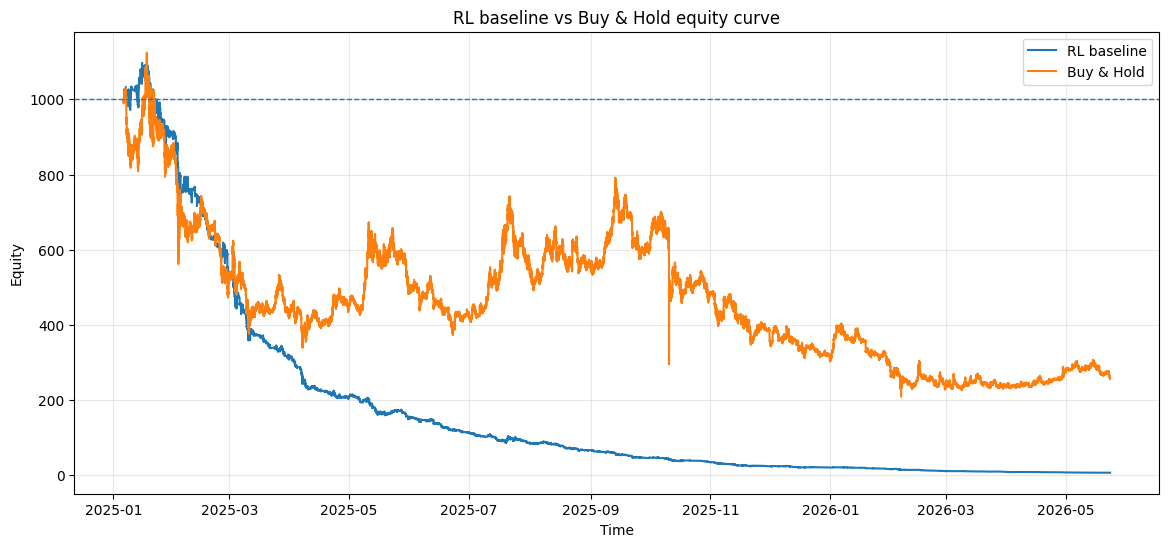

,notebook,strategy,initial_balance,final_balance,return_pct,max_drawdown_pct,sharpe_ratio_approx,num_periods,buy_signals,sell_signals,hold_signals,fees_applied,slippage_applied,position_sizing,main_limitation
0,08_baseline_RL,RL baseline,1000.0,6.646529,-99.335347,-99.398312,-7.406826,144615,15046.0,33602.0,95967.0,0.001,0.0005,All-in long-only when BUY is executed,Simplified tabular Q-learning baseline with di...
1,08_baseline_RL,Buy & Hold,1000.0,258.120019,-74.187998,-81.410760,-0.464415,144615,NaN,NaN,NaN,0.001,0.0005,All-in long-only when BUY is executed,Simplified tabular Q-learning baseline with di...


In [13]:
# ============================================================
# RL vs Buy and Hold comparison
# Se comparan las curvas de equity del agente RL y del benchmark Buy & Hold sobre el mismo periodo de test.
# Además del gráfico, se genera una tabla resumen para documentar métricas comparables dentro del TFM.
# ============================================================

rl_equity = rl_eval_df["equity"].astype(float).reset_index(drop=True)
bh_equity = buy_hold_df["equity"].astype(float).reset_index(drop=True).iloc[:len(rl_equity)]

comparison_df = pd.DataFrame({
    "rl_equity": rl_equity,
    "buy_hold_equity": bh_equity,
})

if "open_time" in rl_eval_df.columns:
    comparison_df["open_time"] = rl_eval_df["open_time"].to_numpy()

x_axis = comparison_df["open_time"] if "open_time" in comparison_df.columns else comparison_df.index

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x_axis, comparison_df["rl_equity"], label="RL baseline")
ax.plot(x_axis, comparison_df["buy_hold_equity"], label="Buy & Hold")
ax.axhline(INITIAL_BALANCE, linestyle="--", linewidth=1)
ax.set_title("RL baseline vs Buy & Hold equity curve")
ax.set_xlabel("Time" if "open_time" in comparison_df.columns else "Step")
ax.set_ylabel("Equity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

summary_rows = [
    summarize_strategy(comparison_df["rl_equity"], "RL baseline", rl_eval_df["action"]),
    summarize_strategy(comparison_df["buy_hold_equity"], "Buy & Hold", None),
]

results_summary_df = pd.DataFrame(summary_rows)
results_summary_df.insert(0, "notebook", "08_baseline_RL")
results_summary_df["fees_applied"] = FEE_RATE
results_summary_df["slippage_applied"] = SLIPPAGE_RATE
results_summary_df["position_sizing"] = "All-in long-only when BUY is executed"
results_summary_df["main_limitation"] = "Simplified tabular Q-learning baseline with discretized state space"

display(results_summary_df)


## Comentarios - Comparativa RL vs Buy & Hold

La comparación principal muestra que el agente RL obtiene un resultado claramente inferior al benchmark pasivo.

El baseline RL termina con un equity de 6,65 sobre un capital inicial de 1.000, equivalente a un retorno aproximado de -99,34 %. Buy & Hold también pierde valor durante el mismo periodo, pero conserva un equity final de 258,12, con un retorno aproximado de -74,19 %.

La diferencia es importante porque indica que el problema no se limita a un periodo de mercado desfavorable: el agente destruye mucho más capital que la referencia pasiva.

El Sharpe aproximado también es peor en el agente RL (-7,41 frente a -0,46), reforzando que la curva no solo cae más, sino que lo hace con una relación retorno-riesgo más negativa.

Esta tabla cumple bien su función dentro del TFM: documenta que la primera aproximación RL es ejecutable y comparable, pero todavía no genera una política competitiva.


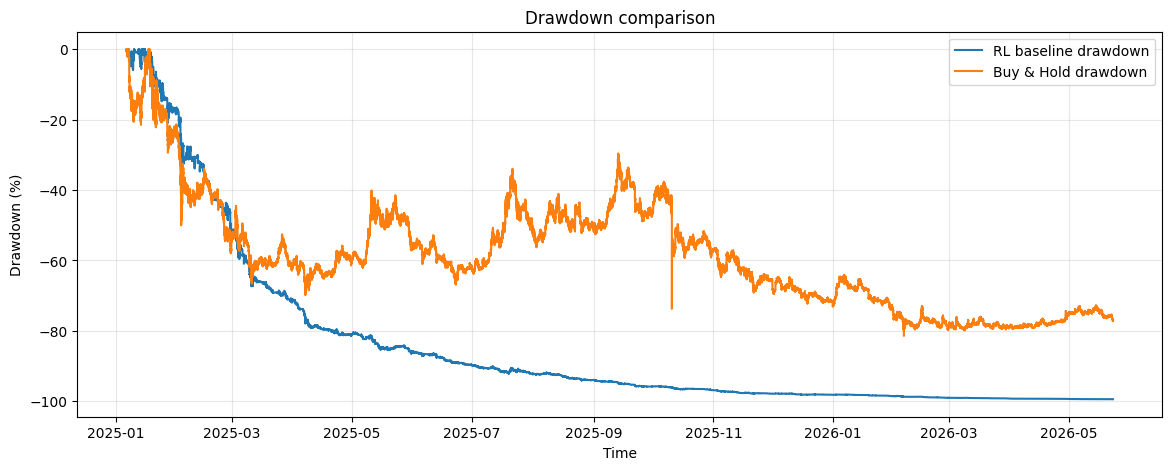

,rl_max_drawdown_pct,buy_hold_max_drawdown_pct,rl_final_equity,buy_hold_final_equity
0,-99.398312,-81.41076,6.646529,258.120019


In [14]:
# ============================================================
# Drawdown comparison
# Se calcula y visualiza el drawdown del agente RL y de Buy & Hold para evaluar riesgo relativo más allá del retorno final.
# La tabla final muestra los valores mínimos de drawdown y facilita su uso posterior en la memoria.
# ============================================================

comparison_df["rl_drawdown"] = compute_drawdown(comparison_df["rl_equity"])
comparison_df["buy_hold_drawdown"] = compute_drawdown(comparison_df["buy_hold_equity"])

x_axis = comparison_df["open_time"] if "open_time" in comparison_df.columns else comparison_df.index

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x_axis, comparison_df["rl_drawdown"] * 100, label="RL baseline drawdown")
ax.plot(x_axis, comparison_df["buy_hold_drawdown"] * 100, label="Buy & Hold drawdown")
ax.set_title("Drawdown comparison")
ax.set_xlabel("Time" if "open_time" in comparison_df.columns else "Step")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

drawdown_summary_df = pd.DataFrame([{
    "rl_max_drawdown_pct": comparison_df["rl_drawdown"].min() * 100,
    "buy_hold_max_drawdown_pct": comparison_df["buy_hold_drawdown"].min() * 100,
    "rl_final_equity": comparison_df["rl_equity"].iloc[-1],
    "buy_hold_final_equity": comparison_df["buy_hold_equity"].iloc[-1],
}])

display(drawdown_summary_df)


## Comentarios - Drawdown

El drawdown confirma el deterioro observado en la curva de equity.

El agente RL alcanza un drawdown máximo aproximado de -99,40 %, frente al -81,41 % de Buy & Hold. En términos prácticos, la estrategia RL queda prácticamente liquidada durante el periodo de test.

Este resultado es coherente con una baseline all-in long-only sin control explícito de riesgo. Cada entrada incorrecta puede afectar a todo el capital disponible, y los costes de transacción amplifican el daño cuando la política cambia de posición con frecuencia.

Como ya se comentó en la comparativa principal, el interés de esta V1 no está en el rendimiento final, sino en dejar una referencia inicial suficientemente clara para justificar mejoras posteriores sobre reward, restricciones operativas y gestión de exposición.


In [15]:
# ============================================================
# Action distribution and trade log
# Se resume la distribución de acciones y las operaciones realmente ejecutadas para detectar políticas degeneradas o exceso de rotación.
# Esto ayuda a interpretar si el agente opera, permanece inactivo o sobreopera durante el periodo de test.
# ============================================================

action_label_map = {0: "HOLD", 1: "BUY", 2: "SELL"}

action_distribution_df = (
    rl_eval_df["action"]
    .map(action_label_map)
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

action_distribution_df["pct"] = action_distribution_df["count"] / action_distribution_df["count"].sum() * 100

display(action_distribution_df)

trade_log_df = pd.DataFrame(test_env.trade_log)

if not trade_log_df.empty and "open_time" in test_df.columns:
    trade_log_df["open_time"] = trade_log_df["step"].apply(lambda idx: test_df.loc[min(idx, len(test_df) - 1), "open_time"])
    trade_log_df = trade_log_df[["open_time", "step", "action", "price"]]

display(trade_log_df.head(20))
print(f"Executed trades in test: {len(trade_log_df)}")


,action,count,pct
0,HOLD,95967,66.360336
1,SELL,33602,23.235487
2,BUY,15046,10.404177


,open_time,step,action,price
0,2025-01-06 14:35:00,92,BUY,0.38325
1,2025-01-06 16:25:00,114,SELL,0.39316
2,2025-01-07 03:30:00,247,BUY,0.39044
3,2025-01-07 04:10:00,255,SELL,0.39312
4,2025-01-07 06:35:00,284,BUY,0.39121
5,2025-01-07 08:20:00,305,SELL,0.39409
6,2025-01-07 10:15:00,328,BUY,0.39223
7,2025-01-07 11:35:00,344,SELL,0.38732
8,2025-01-07 18:35:00,428,BUY,0.35528
9,2025-01-07 19:40:00,441,SELL,0.35271


Executed trades in test: 2936


## Comentarios - Distribución de acciones y operaciones

La política evaluada selecciona HOLD en el 66,36 % de los pasos, SELL en el 23,24 % y BUY en el 10,40 %.

Aunque HOLD es la acción mayoritaria, el número total de operaciones ejecutadas en test asciende a 2.936, una cifra alta para una primera baseline simplificada. Esto indica que el agente no se queda completamente bloqueado, pero sí genera una rotación considerable.

El desequilibrio entre acciones también sugiere una política poco refinada: el agente emite muchas señales SELL aunque solo pueda cerrar una posición larga existente, por lo que parte de esas decisiones no aportan valor operativo real.

En esta versión, la combinación de una discretización simple del espacio de estados, un reward basado en variaciones inmediatas de equity y la ausencia de restricciones operativas favorece una política poco robusta. Este resultado justifica una segunda versión orientada a reducir acciones de bajo valor operativo, penalizar la sobreoperación y controlar de forma más explícita la exposición al mercado.


In [16]:
# ============================================================
# Persist RL results
# Se guardan los resultados principales del baseline RL en la carpeta results para facilitar comparaciones posteriores entre notebooks.
# También se exporta la curva de equity comparativa y el log de operaciones ejecutadas durante test.
# ============================================================

summary_path = RESULTS_DIR / "08_baseline_RL_summary.csv"
equity_path = RESULTS_DIR / "08_baseline_RL_equity_curve.csv"
trades_path = RESULTS_DIR / "08_baseline_RL_trades.csv"
training_path = RESULTS_DIR / "08_baseline_RL_training_metrics.csv"
config_path = RESULTS_DIR / "08_baseline_RL_config.json"

results_summary_df.to_csv(summary_path, index=False)
comparison_df.to_csv(equity_path, index=False)
trade_log_df.to_csv(trades_path, index=False)
training_metrics_df.to_csv(training_path, index=False)

config = {
    "notebook": "08_baseline_RL",
    "data_path": str(DATA_PATH),
    "gym_backend": GYM_BACKEND,
    "initial_balance": INITIAL_BALANCE,
    "fee_rate": FEE_RATE,
    "slippage_rate": SLIPPAGE_RATE,
    "train_fraction": TRAIN_FRACTION,
    "n_episodes": N_EPISODES,
    "max_train_episode_steps": MAX_TRAIN_EPISODE_STEPS,
    "feature_cols": feature_cols,
    "selected_state_features": selected_state_features,
    "rl_algorithm": "Tabular Q-learning with discretized state space",
}

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False, default=str)

saved_files_df = pd.DataFrame({
    "file": [summary_path, equity_path, trades_path, training_path, config_path]
})

display(saved_files_df)


,file
0,..\results\08_baseline_RL_summary.csv
1,..\results\08_baseline_RL_equity_curve.csv
2,..\results\08_baseline_RL_trades.csv
3,..\results\08_baseline_RL_training_metrics.csv
4,..\results\08_baseline_RL_config.json


## Limitaciones del experimento

Este experimento presenta limitaciones importantes:

- El entorno es long-only y no contempla posiciones cortas
- El tamaño de posición es all-in y no optimiza exposición parcial
- El reward no incorpora explícitamente penalización por drawdown ni control avanzado del riesgo
- La discretización del estado reduce mucha información continua del mercado
- El entrenamiento se limita a pocos episodios para mantener bajo el coste computacional
- El agente no utiliza redes neuronales ni replay buffer, por lo que no equivale a un DQN o PPO moderno
- La simulación no modela profundidad de mercado, liquidez real ni latencia de ejecución

Como ya se observó en las tablas anteriores, estas limitaciones no son únicamente teóricas: se reflejan directamente en sobreoperación, drawdown extremo y rendimiento inferior al benchmark pasivo.

Aun así, el notebook cumple el objetivo de implementar un entorno secuencial de trading y evaluar una política RL baseline de forma trazable y comparable con el resto del proyecto.


## Conclusiones - Baseline RL V1

La primera versión del baseline RL permite validar la arquitectura mínima del bloque de aprendizaje por refuerzo planteado en el proyecto.

El notebook construye un entorno secuencial compatible con Gym, define un espacio de acciones BUY/HOLD/SELL, entrena una política Q-learning tabular y evalúa el agente sobre un tramo temporal posterior al entrenamiento.

Desde el punto de vista metodológico, el resultado es positivo: el pipeline funciona, genera métricas comparables y exporta resultados reutilizables en `../results/`.

Desde el punto de vista financiero, el resultado es claramente negativo. El agente termina con una pérdida cercana al 99,34 %, un drawdown máximo aproximado del 99,40 % y un rendimiento significativamente peor que Buy & Hold durante el mismo periodo.

La causa principal no parece ser únicamente el contexto bajista del test, ya que el benchmark pasivo también pierde pero conserva bastante más capital. El problema está asociado a la simplicidad de esta primera configuración: reward inmediato, discretización tabular, position sizing all-in, ausencia de restricciones operativas y falta de control de riesgo.

Esta V1 debe interpretarse como un prototipo funcional de referencia. Su valor no está en superar al benchmark, sino en mostrar una primera implementación RL completa y en identificar con claridad qué elementos deben mejorar.

Las siguientes versiones deberían centrarse en:

- Reducir acciones inválidas o poco útiles
- Penalizar la sobreoperación
- Introducir cooldown entre operaciones
- Usar position sizing parcial
- Incorporar control básico de drawdown
- Añadir filtros de tendencia o volatilidad
- Comparar la evolución de V1, V2 y V3 mediante summaries homogéneos

Con esta lectura, el resultado negativo de V1 no invalida el enfoque RL, sino que proporciona una base experimental clara para construir una narrativa de mejora progresiva.
